## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from src.network.training import train
from src.network.evaluation import evaluate
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import build_transforms, calculate_stats
from src.utils.plotting import plot_training_history

In [3]:
# Load data

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
train_config = {'blur': (5, (0.1, 0.2)), 'noise': 0.01, 'jitter': (0.3, 0.05)}
test_config = {}
train_transform = build_transforms(train_mean, train_std, config=train_config)
test_transform = build_transforms(test_mean, test_std, config=test_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1125 | Test samples: 132
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 5/5 [00:13<00:00,  2.66s/it]



Calculated training mean: [0.5405116677284241, 0.5397956371307373, 0.5381444692611694]
Calculated training std:  [0.10387232899665833, 0.10447882860898972, 0.10541636496782303]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]


Calculated test mean: [0.6565031409263611, 0.6223108768463135, 0.5438199639320374]
Calculated test std:  [0.14106103777885437, 0.14781025052070618, 0.13531261682510376]



In [4]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


## Training

Training on cuda for 15 epochs...


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 | Train: Loss=0.0406 Acc=0.9880  Val: Loss=0.0126 Acc=0.9959   [Saved Best]
Epoch 2/15 | Train: Loss=0.0121 Acc=0.9965  Val: Loss=0.0126 Acc=0.9959  
Epoch 3/15 | Train: Loss=0.0049 Acc=0.9988  Val: Loss=0.0044 Acc=0.9986   [Saved Best]
Epoch 4/15 | Train: Loss=0.0015 Acc=0.9996  Val: Loss=0.0098 Acc=0.9976  
Epoch 5/15 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0164 Acc=0.9950  
Epoch 6/15 | Train: Loss=0.0154 Acc=0.9964  Val: Loss=0.0010 Acc=0.9999   [Saved Best]
Epoch 7/15 | Train: Loss=0.0004 Acc=0.9999  Val: Loss=0.0001 Acc=1.0000   [Saved Best]
Epoch 8/15 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0004 Acc=0.9999  
Epoch 9/15 | Train: Loss=0.0111 Acc=0.9976  Val: Loss=0.0073 Acc=0.9977  
Epoch 10/15 | Train: Loss=0.0006 Acc=0.9999  Val: Loss=0.0032 Acc=0.9991  
Epoch 11/15 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0022 Acc=0.9994  
Epoch 12/15 | Train: Loss=0.0040 Acc=0.9991  Val: Loss=0.0200 Acc=0.9942  
Epoch 13/15 | Train: Loss=0.0042 Acc=0.9990  Val: Loss=0.

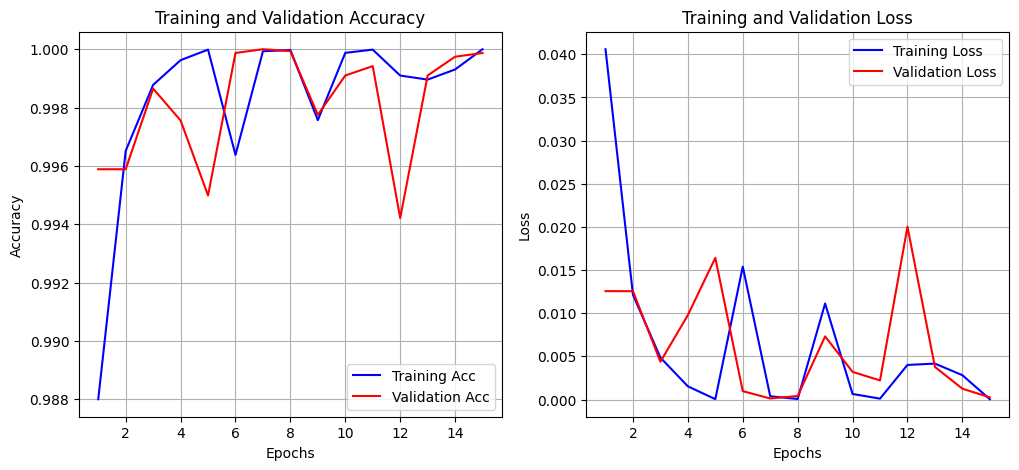

In [7]:
# Training loop

# Configuration
lr = 1e-3
num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path='baseline_naive_data_with_augmentations.pth'
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [8]:
# Evaluation on real test data

square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 132 boards...


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Square accuracy: 66.89
Board accuracy: 0.00
